### Available Data Sources
For this analysis, we will use data from the [Pacific Northwest National Laboratory's Data Center Atlas](https://im3.pnnl.gov/datacenter-atlas) (PNNL) and the [FracTracker Alliance's National Data Centers Tracker](https://www.fractracker.org/2025/07/national-data-centers-tracker/) (FTA).

The PNNL dataset contains locations of existing data center facilities in the United States. Data center locations were derived from OpenStreetMap (OSM), a crowd-sourced database. Data points from OSM are processed in various ways to determine additional variables provided in the data including: facility area (square feet), associated US county, and US state.

The FTA data set maps existing, permitted, and proposed data-center facilities across the U.S., built to analyze their environmental, regulatory, and energy impacts.

##### Variables

Original PNNL:
- **id** - unique identification number (OSM-provided with prefix of "node/", "relation/" and similar attributes removed).
- **state**
- **state_abb**
- **state_id**
- **county**
- **county_id**
- **ref** - reference numbers or codes (OSM-provided).
- **operator** - the name of the company, corporation, or person in charge facility (OSM-provided).
- **name** - name of facility (OSM-provided) 
- **sqft** - surface area of facility polygon, measured in square feet. Only available for "building" and "campus" layers. 
- **lat** - latitude of data centroid point 
- **lon** - longitude of data centroid point 
- **type** – represented spatial information. One of "point", "building", or "campus". 

Original FTA
- **facility_name**: Name of the data center facility or project. This may refer to the official facility name, development project name, or commonly used name in public records or media reports.
- **address**: Street address of the data center facility when available.
- **city**: City or municipality where the facility is located.
- **state**: U.S. state in which the facility is located.
- **zip**: ZIP code corresponding to the facility location.
- **county**: County in which the facility is located.
- **lat**: Latitude coordinate representing the geographic location of the facility.
- **lon**: Longitude coordinate representing the geographic location of the facility.
- **status**: Current stage of the data center project (e.g., existing/operational, under construction, permitted, or proposed).
- **location_confidence**: Indicator of how precise the geographic coordinates are, reflecting whether the location represents an exact facility site or an approximate location.
- **purpose**: Primary function or intended use of the facility, such as cloud computing, artificial intelligence workloads, hyperscale data processing, or colocation services.
- **operator_name**: Company responsible for operating or managing the data center facility.
- **tenant**: Major tenant(s) or companies leasing computing capacity within the facility.
- **mw**: Estimated or reported electrical capacity of the data center, measured in megawatts (MW).
- **sizerank**: Relative ranking or categorical classification of the facility’s size within the dataset, typically based on power capacity or facility scale.
- **power_source**: Primary source of electricity used to power the data center (e.g., grid electricity, natural gas, renewable energy, or mixed sources).
- **dedicated_power_plant**: Indicator of whether the data center is supported by a dedicated power generation facility built specifically to supply its electricity demand.
- **number_of_generators**: Number of backup generators installed or planned at the facility, typically used to provide power during grid outages.
- **number_of_buildings**: Number of buildings or structures comprising the data center campus.
- **cooling_source**: Source of water or other medium used for cooling the facility (e.g., municipal water supply, groundwater, surface water, or recycled water).
- **cooling_type**: Type of cooling technology used at the facility, such as air cooling, evaporative cooling, liquid cooling, or hybrid systems.
- **facility_size_sqft**: Total building floor area of the data center facility measured in square feet.
- **property_size_acres**: Total land area of the data center site measured in acres.
- **project_cost**: Estimated capital cost of constructing the data center project.
- **expected_date_online**: Projected date when the facility is expected to begin operations.
- **community_pushback**: Indicator or notes describing whether local residents or community groups have expressed opposition to the project.
- **advocacy_information**: Additional information about advocacy efforts, community organizing, or campaigns related to the facility.
- **resistance_status**: Categorization of the level or stage of community resistance (e.g., none, emerging opposition, organized campaign, or legal challenges).
- **nda**: Indicates whether a non-disclosure agreement (NDA) is associated with the project, potentially limiting publicly available information about the facility.


### Join Datasets

Join the PNNL and FTA datasets together. Using fuzzy spatial matching, combine both data sets using `lon` and `lat`. We will use the PNNL dataset as the base that the FTA dataset is matched and joined to.

In [1]:
# Import packages
from pathlib import Path
import pandas as pd
import geopandas as gpd
import numpy as np
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS

In [2]:
# -----------------------------
# Paths
# -----------------------------
PROJECT_ROOT = Path.cwd()

IM3_FILE = PROJECT_ROOT / "im3" / "im3_open_source_data_center_atlas_v2026.02.09.csv"
FRACTRACKER_FILE = PROJECT_ROOT / "fta" / "fractracker_database.xlsx"

OUTPUT_FILE = PROJECT_ROOT / "output" / "datacenters_matched.xlsx"

In [3]:
# -----------------------------
# Parameters
# -----------------------------
MAX_DISTANCE_M = 2000

In [4]:
# -----------------------------
# Load data
# -----------------------------
im3 = pd.read_csv(IM3_FILE)
fractracker = pd.read_excel(FRACTRACKER_FILE)

# -----------------------------
# Filter to Virginia
# -----------------------------
im3_va = im3[
    im3["state_abb"].astype(str).str.strip().str.upper().eq("VA")
    | im3["state"].astype(str).str.strip().str.upper().eq("VIRGINIA")
].copy()

fractracker_va = fractracker[
    fractracker["state"].astype(str).str.strip().str.upper().isin(["VA", "VIRGINIA"])
].copy()

In [5]:
# -----------------------------
# Clean coordinates
# -----------------------------
for df in (im3_va, fractracker_va):
    df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
    df["lon"] = pd.to_numeric(df["lon"], errors="coerce")

im3_va = im3_va.dropna(subset=["lat", "lon"]).copy()
fractracker_va = fractracker_va.dropna(subset=["lat", "lon"]).copy()

# Basic coordinate sanity check
im3_va = im3_va[(im3_va["lat"].between(20, 50)) & (im3_va["lon"].between(-130, -60))].copy()
fractracker_va = fractracker_va[
    (fractracker_va["lat"].between(20, 50)) & (fractracker_va["lon"].between(-130, -60))
].copy()

# -----------------------------
# Add IDs so matches are traceable
# -----------------------------
im3_va = im3_va.reset_index(drop=True)
fractracker_va = fractracker_va.reset_index(drop=True)

im3_va["im3_id"] = im3_va.index + 1
fractracker_va["fractracker_id"] = fractracker_va.index + 1

# Rename fractracker columns before join so output is readable
fractracker_va = fractracker_va.rename(
    columns={
        "facility_name": "fractracker_facility_name",
        "address": "fractracker_address",
        "city": "fractracker_city",
        "county": "fractracker_county",
        "operator_name": "fractracker_operator_name",
        "status": "fractracker_status",
        "purpose": "fractracker_purpose",
        "mw": "fractracker_mw",
        "location_confidence": "fractracker_location_confidence",
        "lat": "fractracker_lat",
        "lon": "fractracker_lon",
    }
)

# -----------------------------
# Convert to GeoDataFrames
# -----------------------------
im3_gdf = gpd.GeoDataFrame(
    im3_va,
    geometry=gpd.points_from_xy(im3_va["lon"], im3_va["lat"]),
    crs="EPSG:4326",
)

fractracker_gdf = gpd.GeoDataFrame(
    fractracker_va,
    geometry=gpd.points_from_xy(fractracker_va["fractracker_lon"], fractracker_va["fractracker_lat"]),
    crs="EPSG:4326",
)

# Reproject so distance is in meters
# EPSG:3857 is acceptable for this matching task
im3_proj = im3_gdf.to_crs(epsg=3857)
fractracker_proj = fractracker_gdf.to_crs(epsg=3857)

# -----------------------------
# Nearest-neighbor fuzzy spatial match
# Keep all im3 rows
# -----------------------------
matched = gpd.sjoin_nearest(
    im3_proj,
    fractracker_proj,
    how="left",
    max_distance=MAX_DISTANCE_M,
    distance_col="match_distance_m",
    lsuffix="im3",
    rsuffix="fractracker",
)

# Drop geometry and index artifacts
matched = matched.drop(columns=["geometry", "index_fractracker"], errors="ignore")

# Flag matched rows
matched["matched_flag"] = matched["fractracker_id"].notna().astype(int)

# Match quality buckets
def classify_match(distance):
    if pd.isna(distance):
        return "no match"
    if distance <= 500:
        return "strong"
    if distance <= 2000:
        return "plausible"
    return "weak"

matched["match_quality"] = matched["match_distance_m"].apply(classify_match)

# -----------------------------
# Optional name similarity check
# -----------------------------
from difflib import SequenceMatcher

def name_similarity(a, b):
    if pd.isna(a) or pd.isna(b):
        return None
    return SequenceMatcher(None, str(a).lower(), str(b).lower()).ratio()

matched["name_similarity"] = matched.apply(
    lambda row: name_similarity(row.get("name"), row.get("fractracker_facility_name")),
    axis=1,
)

# -----------------------------
# Save & Remove unwanted columns
# -----------------------------

# Convert facility_size_sqft from string to numeric
matched["facility_size_sqft"] = (
    matched["facility_size_sqft"]
    .astype(str)
    .str.replace(",", "", regex=False)   # remove thousand separators
    .str.strip()
)

matched["facility_size_sqft"] = pd.to_numeric(
    matched["facility_size_sqft"],
    errors="coerce"
)

# Columns from Fractracker we do NOT want in the final dataset
drop_columns = [
    "state_fractracker",
    "fractracker_purpose",
    "tenant",
    "power_source",
    "dedicated_power_plant",
    "number_of_generators",
    "number_of_buildings",
    "cooling_source",
    "cooling_type",
    "project_cost",
    "expected_date_online",
    "community_pushback",
    "advocacy_information",
    "resistance_status",
    "nda",
    "community_group_website_1",
    "community_group_website_2",
    "petition_url",
    "info_source_1",
    "info_source_2",
    "info_source_3",
    "info_source_4",
    "info_source_5",
    "info_source_6",
    "info_source_7",
    "info_source_8",
    "date_created",
    "date_updated"
]


# remove unwanted fractracker variables
matched = matched.drop(columns=drop_columns, errors="ignore")

matched.to_excel(OUTPUT_FILE, index=False)

# -----------------------------
# Print summary
# -----------------------------
print(f"im3 Virginia rows: {len(im3_va)}")
print(f"fractracker Virginia rows: {len(fractracker_va)}")
print(f"Matched im3 rows: {matched['matched_flag'].sum()}")
print(f"Unmatched im3 rows: {(matched['matched_flag'] == 0).sum()}")
print(f"Output written to: {OUTPUT_FILE}")

im3 Virginia rows: 319
fractracker Virginia rows: 452
Matched im3 rows: 316
Unmatched im3 rows: 3
Output written to: c:\Corbin_Documents\Hertie, Class of 2026\Course Work\Theses\2025-26\Master-Thesis-2026\output\datacenters_matched.xlsx


### Years of Operation

Using the PNNL dataset as a basis, we collected the beginning year of operation for eact data center when it was available. If the beginning date of operation was not available, we also collected year construction completion and the announcement year.

In [6]:
PNNL_YRS_FILE = PROJECT_ROOT / "im3_years" / "va_pnnl_researched.xlsx"

pnnl_yrs = pd.read_excel(PNNL_YRS_FILE)

pnnl_yrs.columns = pnnl_yrs.columns.str.strip().str.lower().str.replace(" ", "_")

In [7]:
# Subset to relevant columns for merging with main dataset

pnnl_yrs_subset = pnnl_yrs[
    ["id", "research_year", "year_basis_used", "year_source_link"]
].copy()

In [8]:
matched = matched.merge(
    pnnl_yrs_subset,
    on="id",
    how="left"
)

matched.to_excel(OUTPUT_FILE, index=False)

### Append to census tract

In [9]:
TRACT_FILE = PROJECT_ROOT / "data" / "raw" / "usa_data" / "virginia_census_data" / "cb_2024_51_tract_500k.zip"
# replace your-folder-name with the actual folder holding the zip

# 1. Read census tract polygons from zip
tracts = gpd.read_file(TRACT_FILE)

# 2. Check tract columns
print(tracts.columns.tolist())

# 3. Convert your output dataset to GeoDataFrame using im3 lon/lat
matched_gdf = gpd.GeoDataFrame(
    matched.copy(),
    geometry=gpd.points_from_xy(matched["lon"], matched["lat"]),
    crs="EPSG:4326"
)

# 4. Make sure both layers use the same CRS
tracts = tracts.to_crs(matched_gdf.crs)

# 5. Keep only the tract columns you want
tracts_keep = tracts[["GEOID", "NAME", "STATEFP", "COUNTYFP", "TRACTCE", "geometry"]].copy()

# 6. Spatial join: assign each point to the tract polygon it falls within
matched_with_tract = gpd.sjoin(
    matched_gdf,
    tracts_keep,
    how="left",
    predicate="within"
)

# 7. Clean up join artifacts
matched_with_tract = matched_with_tract.drop(columns=["geometry", "index_right"], errors="ignore")

# 8. Optional: rename tract variables for clarity
matched_with_tract = matched_with_tract.rename(columns={
    "GEOID": "census_tract_geoid",
    "NAME": "census_tract_name",
    "STATEFP": "census_statefp",
    "COUNTYFP": "census_countyfp",
    "TRACTCE": "census_tractce"
})

print(matched_with_tract[[
    "id", "census_tract_geoid", "census_tract_name"
]].head())

['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOIDFQ', 'GEOID', 'NAME', 'NAMELSAD', 'STUSPS', 'NAMELSADCO', 'STATE_NAME', 'LSAD', 'ALAND', 'AWATER', 'geometry']
         id census_tract_geoid census_tract_name
0  14997588        51087201404           2014.04
1  19787207        51153901504           9015.04
2  45583050        51153901503           9015.03
3  45776978        51153901418           9014.18
4  45776979        51153901418           9014.18


In [10]:
final_output = matched_with_tract.copy()

OUTPUT_FILE = PROJECT_ROOT / "output" / "datacenters_matched_tracts.xlsx"
final_output.to_excel(OUTPUT_FILE, index=False)
print("Saved to:", OUTPUT_FILE)

Saved to: c:\Corbin_Documents\Hertie, Class of 2026\Course Work\Theses\2025-26\Master-Thesis-2026\output\datacenters_matched_tracts.xlsx


### Assign treatment to census tracts in Virginia for difference-in-differences estimation

The time period we are interested in is 2015 to 2025. For each census tract that receives a new data center during that time period, we assign it treatment. All other census tracts that do not receive a new data center in the defined period are assigned control.

In [20]:
# Import our data center dataset matched to tracts, subset to those with research years for analysis (2018-2025). Import LMP file matched to tracts.
DC_FILE = PROJECT_ROOT / "output" / "datacenters_matched_tracts.xlsx"
LMP_FILE = PROJECT_ROOT / "data" / "processed" / "usa_data" / "va_lmp_yearly_avg_geo.csv"

dc = pd.read_excel(DC_FILE)
lmp = pd.read_csv(LMP_FILE)

dc.columns = dc.columns.str.strip().str.lower()
lmp.columns = lmp.columns.str.strip().str.lower()

In [21]:
# Clean and convert key variables

dc["census_tract_geoid"] = dc["census_tract_geoid"].astype(str).str.strip().str.zfill(11)
dc["research_year"] = pd.to_numeric(dc["research_year"], errors="coerce")

treat_years = (
    dc.loc[
        dc["census_tract_geoid"].notna() &
        dc["research_year"].between(2015, 2025, inclusive="both"),
        ["census_tract_geoid", "research_year"]
    ]
    .groupby("census_tract_geoid", as_index=False)["research_year"]
    .min()
    .rename(columns={
        "census_tract_geoid": "geoid",
        "research_year": "first_treat_year"
    })
)

lmp = lmp.rename(columns={"census_geoid": "geoid"})

print("Unique treated tracts:", len(treat_years))
print(treat_years["first_treat_year"].value_counts().sort_index())

Unique treated tracts: 36
first_treat_year
2015     2
2016     2
2017    10
2018     2
2019     3
2020     2
2021     2
2022     2
2023     2
2024     7
2025     2
Name: count, dtype: int64


Create treatment timing variable; treatment tracts receive a data center between 2015 and 2025. Define each tract's first year as the earliest `research_year` within the range.

In [22]:
dc_treat = dc[
    dc["census_tract_geoid"].notna() &
    dc["research_year"].between(2015, 2025, inclusive="both")
].copy()

treat_years = (
    dc_treat.groupby("census_tract_geoid", as_index=False)["research_year"]
    .min()
    .rename(columns={
        "census_tract_geoid": "geoid",
        "research_year": "first_treat_year"
    })
)

print(treat_years.head())
print("Number of treated tracts:", len(treat_years))

         geoid  first_treat_year
0  51059460503              2016
1  51059471201              2019
2  51059480902              2017
3  51059481202              2025
4  51059482505              2024
Number of treated tracts: 36


In [23]:
lmp["geoid"] = lmp["geoid"].astype(str).str.strip().str.zfill(11)
lmp["year"] = pd.to_numeric(lmp["year"], errors="coerce")
lmp["avg_total_lmp"] = pd.to_numeric(lmp["avg_total_lmp"], errors="coerce")

lmp_clean = (
    lmp.groupby(["geoid", "year"], as_index=False)
    .agg(
        avg_total_lmp=("avg_total_lmp", "mean"),
        avg_energy=("avg_energy", "mean"),
        avg_congestion=("avg_congestion", "mean"),
        avg_loss=("avg_loss", "mean")
    )
)

print(lmp_clean.groupby(["geoid", "year"]).size().value_counts())

1    3792
Name: count, dtype: int64


In [24]:
# Merge treatment timing into the LMP tract-year panel

panel = lmp_clean.merge(
    treat_years,
    on="geoid",
    how="left"
)

panel["ever_treated"] = panel["first_treat_year"].notna().astype(int)

panel["treated_it"] = (
    panel["first_treat_year"].notna() &
    (panel["year"] >= panel["first_treat_year"])
).astype(int)

In [25]:
print("Duplicate tract-years:")
print(panel.groupby(["geoid", "year"]).size().value_counts().sort_index())

print("\nEver treated tracts:")
print(panel.groupby("geoid")["ever_treated"].max().value_counts())

print("\nYears per tract:")
print(panel.groupby("geoid")["year"].nunique().describe())

Duplicate tract-years:
1    3792
Name: count, dtype: int64

Ever treated tracts:
ever_treated
0    344
1     11
Name: count, dtype: int64

Years per tract:
count    355.000000
mean      10.681690
std        1.387017
min        1.000000
25%       11.000000
50%       11.000000
75%       11.000000
max       11.000000
Name: year, dtype: float64


In [26]:
# Creat a treatment indicator: 1 if tract-year is treated, 0 if control

panel["ever_treated"] = panel["first_treat_year"].notna().astype(int)

panel["treated_it"] = np.where(
    panel["first_treat_year"].notna() & (panel["year"] >= panel["first_treat_year"]),
    1,
    0
)

In [27]:
# Print summary of final panel

print(panel[["geoid", "year", "avg_total_lmp", "first_treat_year", "treated_it"]].head(10))
print("Total rows:", len(panel))
print("Unique tracts:", panel["geoid"].nunique())
print("Treated tracts:", panel.loc[panel["ever_treated"] == 1, "geoid"].nunique())
print("Never-treated tracts:", panel.loc[panel["ever_treated"] == 0, "geoid"].nunique())

         geoid  year  avg_total_lmp  first_treat_year  treated_it
0  51001090100  2015      62.212420               NaN           0
1  51001090100  2016      47.004851               NaN           0
2  51001090100  2017      46.050955               NaN           0
3  51001090100  2018      57.931586               NaN           0
4  51001090100  2019      28.692638               NaN           0
5  51001090100  2020      23.416091               NaN           0
6  51001090100  2021      48.378187               NaN           0
7  51001090100  2022      81.388040               NaN           0
8  51001090100  2023      40.294011               NaN           0
9  51001090100  2024      41.633694               NaN           0
Total rows: 3792
Unique tracts: 355
Treated tracts: 11
Never-treated tracts: 344


In [ ]:
# Check balance of treated vs. never-treated tracts on pre-treatment LMP (2015-2019)
years_per_tract = panel.groupby("geoid")["year"].nunique()
print(years_per_tract.describe())

count    355.000000
mean      10.681690
std        1.387017
min        1.000000
25%       11.000000
50%       11.000000
75%       11.000000
max       11.000000
Name: year, dtype: float64


balance test - integrate

In [34]:
balanced_geoids = panel.groupby("geoid")["year"].nunique()
balanced_geoids = balanced_geoids[balanced_geoids == 11].index  # 2015–2025

panel_bal = panel[panel["geoid"].isin(balanced_geoids)].copy()

In [35]:
print("Original tracts:", panel["geoid"].nunique())
print("Balanced tracts:", panel_bal["geoid"].nunique())

Original tracts: 355
Balanced tracts: 331


In [36]:
panel_bal_fe = panel_bal.set_index(["geoid", "year"]).sort_index()

In [37]:
for y in outcomes:

    mod = PanelOLS.from_formula(
        f"{y} ~ 1 + treated_it + EntityEffects + TimeEffects",
        data=panel_bal_fe
    )

    res = mod.fit(cov_type="clustered", cluster_entity=True)

    print("\n==============================")
    print(f"[BALANCED] Outcome: {y}")
    print(res.summary)


[BALANCED] Outcome: avg_total_lmp
                          PanelOLS Estimation Summary                           
Dep. Variable:          avg_total_lmp   R-squared:                        0.0171
Estimator:                   PanelOLS   R-squared (Between):              0.0470
No. Observations:                3641   R-squared (Within):               0.0026
Date:                Sun, Apr 19 2026   R-squared (Overall):              0.0039
Time:                        11:09:56   Log-likelihood                   -9231.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      57.479
Entities:                         331   P-value                           0.0000
Avg Obs:                       11.000   Distribution:                  F(1,3299)
Min Obs:                       11.000                                           
Max Obs:                       11.000   F-statistic (robust):             

### Baseline DID
Run a standard two-way fixed effects regression.

In [29]:
# Difference-in-Differences regression with tract and year fixed effects, clustering standard errors at the tract level. Construct panel data structure.

panel_fe = panel.set_index(["geoid", "year"]).sort_index()

outcomes = [
    "avg_total_lmp",
    "avg_energy",
    "avg_congestion",
    "avg_loss"
]

for y in outcomes:

    mod = PanelOLS.from_formula(
        f"{y} ~ 1 + treated_it + EntityEffects + TimeEffects",
        data=panel_fe
    )

    res = mod.fit(cov_type="clustered", cluster_entity=True)

    print("\n==============================")
    print(f"Outcome: {y}")
    print(res.summary)


Outcome: avg_total_lmp
                          PanelOLS Estimation Summary                           
Dep. Variable:          avg_total_lmp   R-squared:                        0.0116
Estimator:                   PanelOLS   R-squared (Between):              0.0255
No. Observations:                3792   R-squared (Within):               0.0025
Date:                Sun, Apr 19 2026   R-squared (Overall):              0.0041
Time:                        10:59:12   Log-likelihood                   -9870.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      40.319
Entities:                         355   P-value                           0.0000
Avg Obs:                       10.682   Distribution:                  F(1,3426)
Min Obs:                       1.0000                                           
Max Obs:                       11.000   F-statistic (robust):             6.6913
    

In [30]:
# Event time
panel["event_time"] = panel["year"] - panel["first_treat_year"]

# Bin event time
panel["event_time_binned"] = panel["event_time"].clip(lower=-4, upper=4)

# Create clean dummy names
event_map = {
    -4: "event_m4",
    -3: "event_m3",
    -2: "event_m2",
     0: "event_0",
     1: "event_p1",
     2: "event_p2",
     3: "event_p3",
     4: "event_p4",
}

for k, varname in event_map.items():
    panel[varname] = (
        panel["first_treat_year"].notna() &
        (panel["event_time_binned"] == k)
    ).astype(int)

In [31]:
from linearmodels.panel import PanelOLS

panel_es = panel.set_index(["geoid", "year"]).sort_index()

event_vars = " + ".join(event_map.values())

mod_es = PanelOLS.from_formula(
    f"avg_total_lmp ~ 1 + {event_vars} + EntityEffects + TimeEffects",
    data=panel_es
)

res_es = mod_es.fit(cov_type="clustered", cluster_entity=True)
print(res_es.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:          avg_total_lmp   R-squared:                        0.0309
Estimator:                   PanelOLS   R-squared (Between):              0.0127
No. Observations:                3792   R-squared (Within):               0.0051
Date:                Sun, Apr 19 2026   R-squared (Overall):              0.0064
Time:                        10:59:23   Log-likelihood                   -9832.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      13.635
Entities:                         355   P-value                           0.0000
Avg Obs:                       10.682   Distribution:                  F(8,3419)
Min Obs:                       1.0000                                           
Max Obs:                       11.000   F-statistic (robust):             5.0837
                            

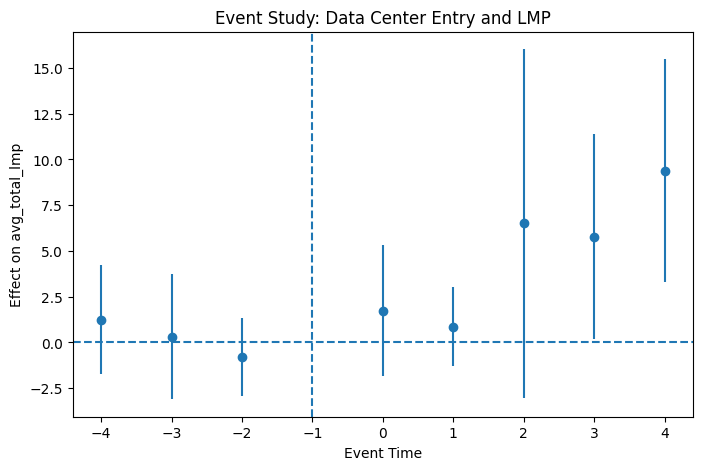

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

coef_order = ["event_m4", "event_m3", "event_m2", "event_0", "event_p1", "event_p2", "event_p3", "event_p4"]
event_time_labels = [-4, -3, -2, 0, 1, 2, 3, 4]

coefs = res_es.params[coef_order]
ses = res_es.std_errors[coef_order]

plot_df = pd.DataFrame({
    "event_time": event_time_labels,
    "coef": coefs.values,
    "se": ses.values
})

plot_df["lower"] = plot_df["coef"] - 1.96 * plot_df["se"]
plot_df["upper"] = plot_df["coef"] + 1.96 * plot_df["se"]

plt.figure(figsize=(8, 5))
plt.errorbar(plot_df["event_time"], plot_df["coef"],
             yerr=1.96 * plot_df["se"], fmt="o")
plt.axhline(0, linestyle="--")
plt.axvline(-1, linestyle="--")
plt.xlabel("Event Time")
plt.ylabel("Effect on avg_total_lmp")
plt.title("Event Study: Data Center Entry and LMP")
plt.show()

Treatment staggered across years; investiate pre-trends